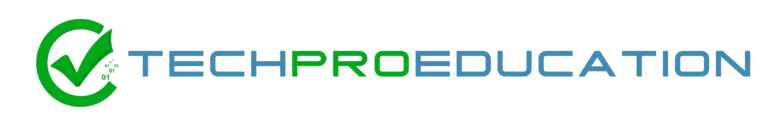

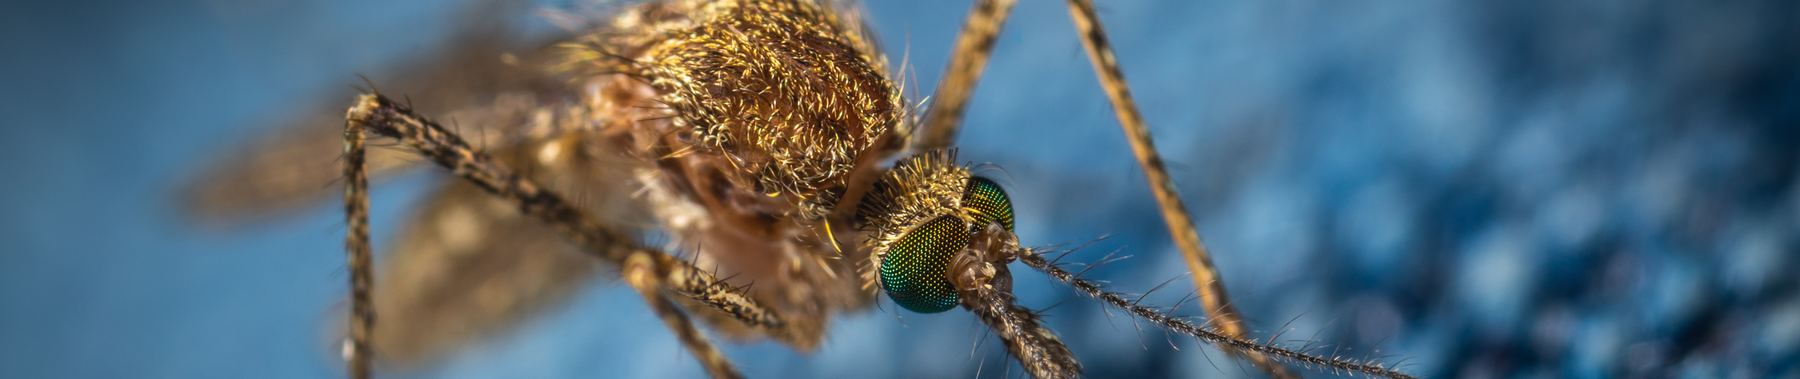

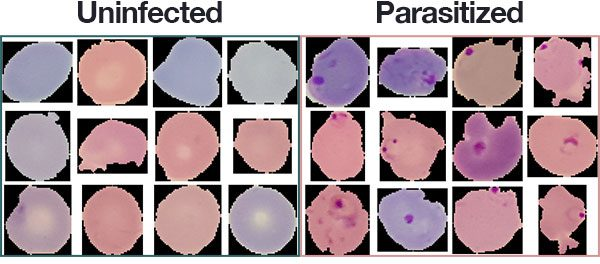

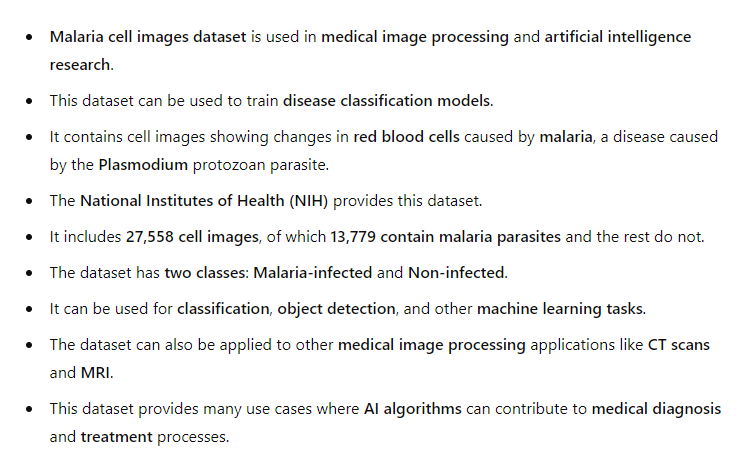

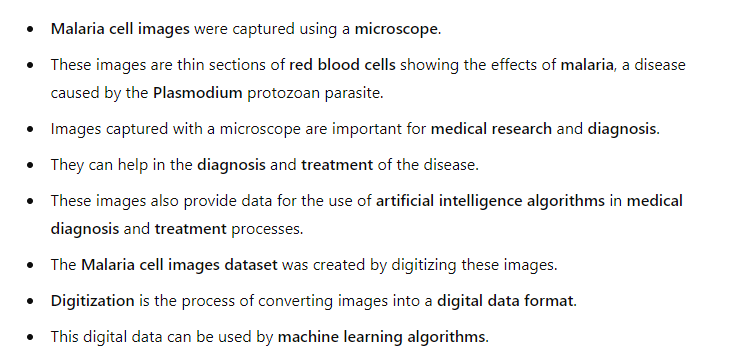

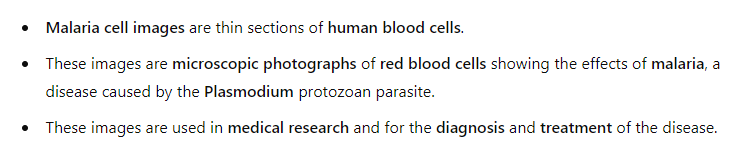


# CNN With Custom Images: Malaria Cell Images Dataset

The dataset contains 2 folders - Infected - Uninfected

And a total of 27,558 images.


This Dataset was taken from the official NIH Website: https://ceb.nlm.nih.gov/repositories/malaria-datasets/ 

Kaggle: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria

In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

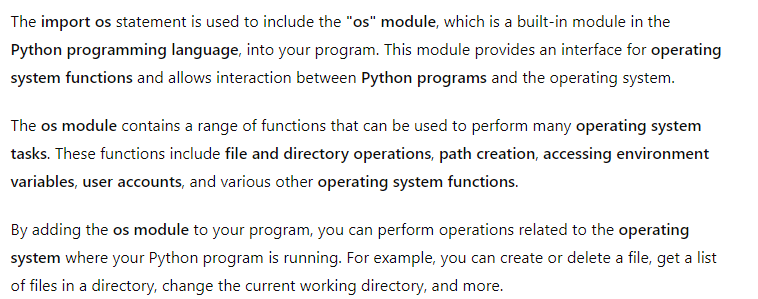

In [2]:
os.getcwd()

'C:\\Users\\jawed\\Desktop\\B287 DL\\04 CNN\\Repo Notebooks\\05 Malaria'

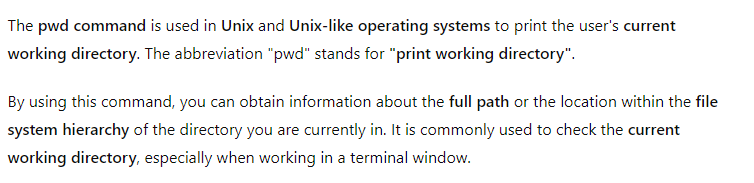

In [3]:
my_data= 'cell_images' # It connects to the image file in the folder specified with pwd. 

In [4]:
os.listdir(my_data) # It shows which folders are in the "cell_images" file.

['test', 'train']

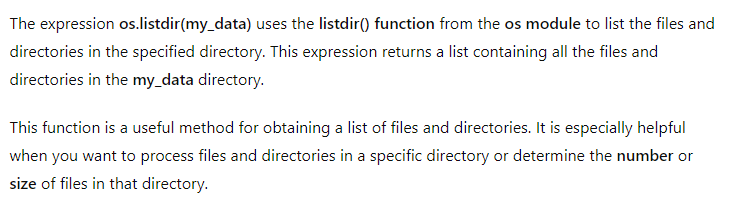

In [5]:
train_path = my_data+'/train/'# Links to "train" data in the "cell_images" file.
test_path = my_data+'/test/' # Links to "test" data in the "cell_images" file.

In [6]:
os.listdir(train_path) # os: operation system. Shows items in the "train_path"

['parasitized', 'uninfected']

In [7]:
os.listdir(test_path) # os: operation system. Shows items in the "test_path"

['parasitized', 'uninfected']

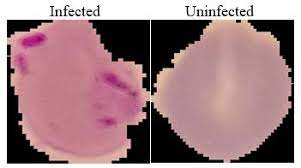

In [8]:
os.listdir(train_path+'parasitized')[:30] # It selects 30 observations for the "parasitized" parts in the "train" cells.

['C100P61ThinF_IMG_20150918_144104_cell_162.png',
 'C100P61ThinF_IMG_20150918_144104_cell_163.png',
 'C100P61ThinF_IMG_20150918_144104_cell_164.png',
 'C100P61ThinF_IMG_20150918_144104_cell_165.png',
 'C100P61ThinF_IMG_20150918_144104_cell_166.png',
 'C100P61ThinF_IMG_20150918_144104_cell_167.png',
 'C100P61ThinF_IMG_20150918_144104_cell_168.png',
 'C100P61ThinF_IMG_20150918_144104_cell_169.png',
 'C100P61ThinF_IMG_20150918_144104_cell_170.png',
 'C100P61ThinF_IMG_20150918_144104_cell_171.png',
 'C100P61ThinF_IMG_20150918_144348_cell_138.png',
 'C100P61ThinF_IMG_20150918_144348_cell_139.png',
 'C100P61ThinF_IMG_20150918_144348_cell_140.png',
 'C100P61ThinF_IMG_20150918_144348_cell_141.png',
 'C100P61ThinF_IMG_20150918_144348_cell_142.png',
 'C100P61ThinF_IMG_20150918_144348_cell_143.png',
 'C100P61ThinF_IMG_20150918_144823_cell_157.png',
 'C100P61ThinF_IMG_20150918_144823_cell_158.png',
 'C100P61ThinF_IMG_20150918_144823_cell_159.png',
 'C100P61ThinF_IMG_20150918_144823_cell_160.png',


In [9]:
os.listdir(train_path+'parasitized')[17] # It shows 18th observations for the "parasitized" parts in the "train" cells.

'C100P61ThinF_IMG_20150918_144823_cell_158.png'

In [10]:
para_cell = train_path+'parasitized'+'/C100P61ThinF_IMG_20150918_144823_cell_158.png'

In [11]:
imread(para_cell)            # "imread" returns a numpy array containing the image's pixel values.

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

In [12]:
para_img= imread(para_cell) # It assigns the image read with "imread" to the "para_img" variable.

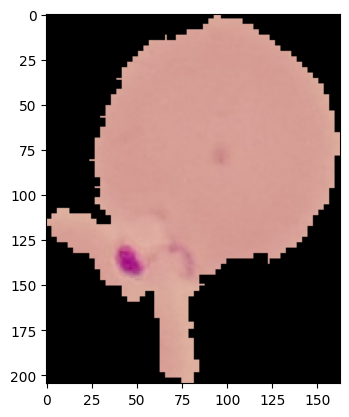

In [13]:
plt.imshow(para_img);

In [14]:
para_img.shape # Size 205x163 and RGB (coloured image).

(205, 163, 3)

In [15]:
os.listdir(train_path+'uninfected')[:20] # Returns 20 uninfected images from the same folder.

['C100P61ThinF_IMG_20150918_144104_cell_128.png',
 'C100P61ThinF_IMG_20150918_144104_cell_131.png',
 'C100P61ThinF_IMG_20150918_144104_cell_144.png',
 'C100P61ThinF_IMG_20150918_144104_cell_21.png',
 'C100P61ThinF_IMG_20150918_144104_cell_25.png',
 'C100P61ThinF_IMG_20150918_144104_cell_48.png',
 'C100P61ThinF_IMG_20150918_144104_cell_65.png',
 'C100P61ThinF_IMG_20150918_144348_cell_120.png',
 'C100P61ThinF_IMG_20150918_144348_cell_125.png',
 'C100P61ThinF_IMG_20150918_144348_cell_131.png',
 'C100P61ThinF_IMG_20150918_144348_cell_2.png',
 'C100P61ThinF_IMG_20150918_144348_cell_25.png',
 'C100P61ThinF_IMG_20150918_144348_cell_40.png',
 'C100P61ThinF_IMG_20150918_144348_cell_71.png',
 'C100P61ThinF_IMG_20150918_144823_cell_126.png',
 'C100P61ThinF_IMG_20150918_144823_cell_127.png',
 'C100P61ThinF_IMG_20150918_144823_cell_139.png',
 'C100P61ThinF_IMG_20150918_144823_cell_142.png',
 'C100P61ThinF_IMG_20150918_144823_cell_151.png',
 'C100P61ThinF_IMG_20150918_144823_cell_21.png']

In [16]:
uninfected_cell_path = train_path+'uninfected/'+os.listdir(train_path+'uninfected')[7]

In [17]:
uninfected_cell_path

'cell_images/train/uninfected/C100P61ThinF_IMG_20150918_144348_cell_120.png'

In [18]:
imread(uninfected_cell_path)

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

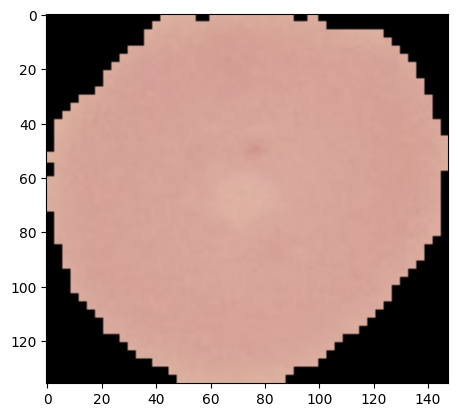

In [19]:
uninfected_cell = imread(uninfected_cell_path)
plt.imshow(uninfected_cell);

**Let's check how many images there are.**

In [20]:
len(os.listdir(train_path+'parasitized'))

12480

In [21]:
len(os.listdir(train_path+'uninfected'))

12480

* It is a **balanced** data.

**Let's find out the average dimensions of these images.**

In [22]:
uninfected_cell.shape  # Index 7

(136, 148, 3)

In [23]:
para_img.shape    # Index 17

(205, 163, 3)

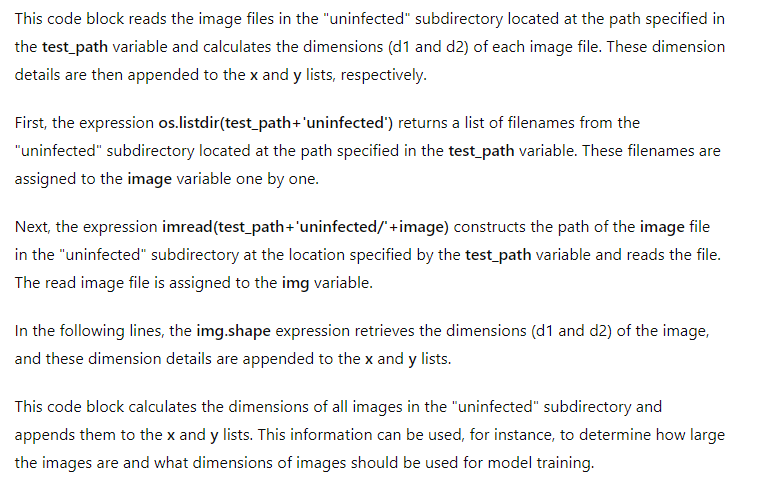

In [24]:
x = []
y = []
for image in os.listdir(test_path+'uninfected'):
    
    img = imread(test_path+'uninfected/'+image)
    d1,d2,_ = img.shape  # d1 and d2 necessary, but last one (RGB) is not. SO, we can use "_" for that unimportant data. 
    x.append(d1)
    y.append(d2)

In [25]:
y[:20]

[118,
 145,
 151,
 145,
 139,
 136,
 160,
 121,
 142,
 121,
 100,
 151,
 139,
 151,
 112,
 124,
 145,
 115,
 166,
 130]

In [26]:
x[:20]

[118,
 172,
 130,
 163,
 172,
 139,
 151,
 160,
 145,
 127,
 121,
 154,
 145,
 127,
 154,
 151,
 148,
 130,
 160,
 136]

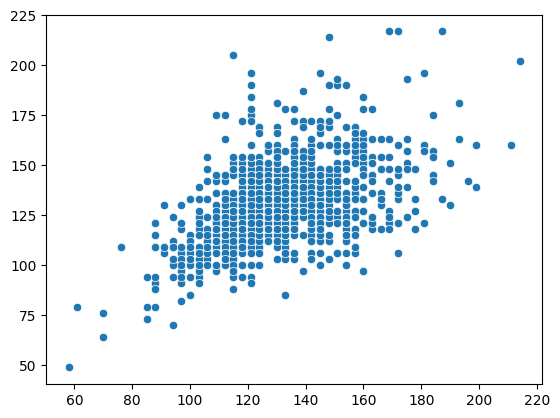

In [27]:
sns.scatterplot(x=x,y=y); # For see average size of images.

In [28]:
np.mean(x)

np.float64(130.92538461538462)

In [29]:
np.mean(y)

np.float64(130.75)

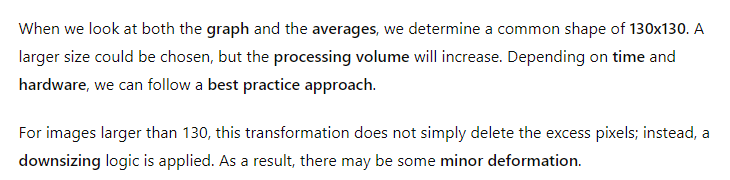

In [30]:
image_shape = (130,130,3) # For convert all data to same size

## Preparing the Data for the model

In [31]:
uninfected_cell.max()

np.float32(0.88235295)

In [32]:
para_img.max()

np.float32(0.8980392)

While we would normally expect min=0 and max=255, we see that a **scaling process has been applied** earlier.

### Image Generator

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
image_gen = ImageDataGenerator(rotation_range=15, 
                               width_shift_range=0.10, 
                               height_shift_range=0.10, 
                               #rescale=1/255,           ==> data was scaled before
                               shear_range=0.1, 
                               zoom_range=0.1, 
                               horizontal_flip=True, 
                               fill_mode='nearest')

This process does not concretely **replicate** the existing data but provides **diversity** through various **transformations** as it goes to the model.

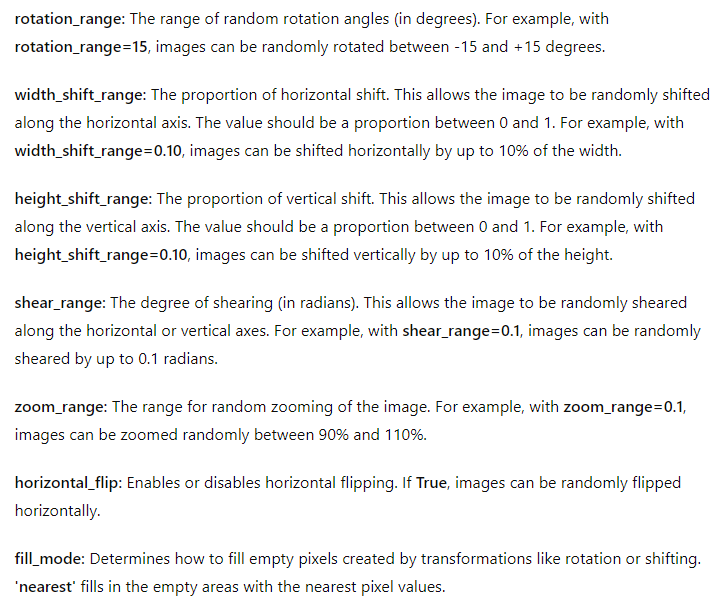

In [35]:
image_gen.flow_from_directory(train_path) 

Found 24958 images belonging to 2 classes.


In [36]:
image_gen.flow_from_directory(test_path) 

Found 2600 images belonging to 2 classes.


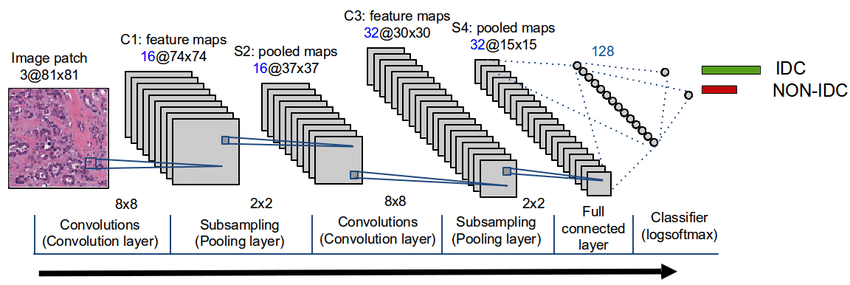

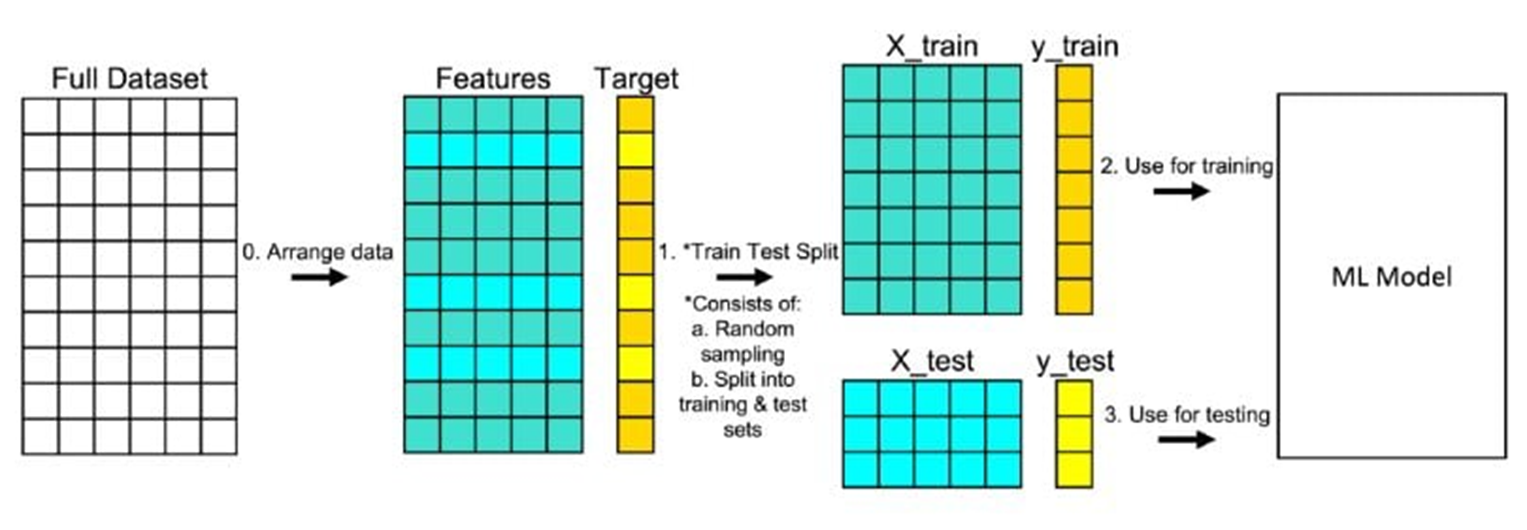

# Creating the Model

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization

In [38]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, padding='same', activation='relu',))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu',))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu',))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

#model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu',))
#model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu',))
#model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu',))
#model.add(MaxPooling2D(pool_size=(2, 2)))

#model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu',))
#model.add(MaxPooling2D(pool_size=(2, 2)))

#model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu',))
#model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())


model.add(Dense(64))


model.add(Activation('relu'))

#model.add(Dropout(0.3))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 130, 130, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 130, 130, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 65, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 65, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 65, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,191,425 (8.36 MB)

 Trainable params: 2,190,977 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

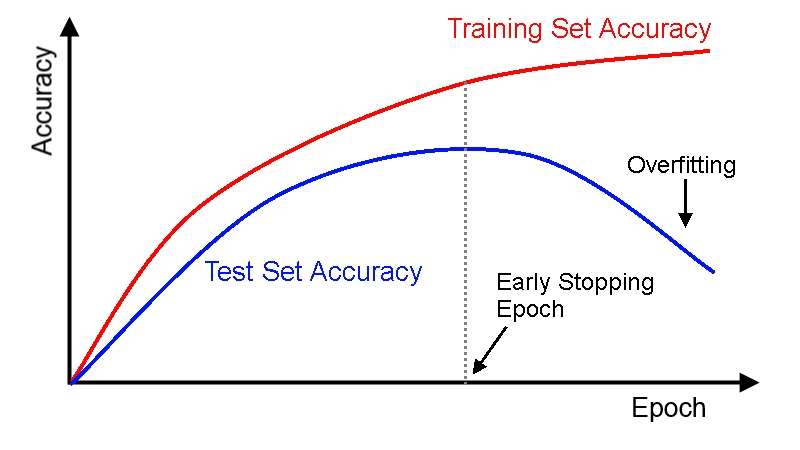

## Early Stopping

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

## Training the Model

### Image Generation for Train Data

In [42]:
#help(image_gen.flow_from_directory)

In [43]:
batch_size = 32
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(130,130),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True, seed=42)

Found 24958 images belonging to 2 classes.


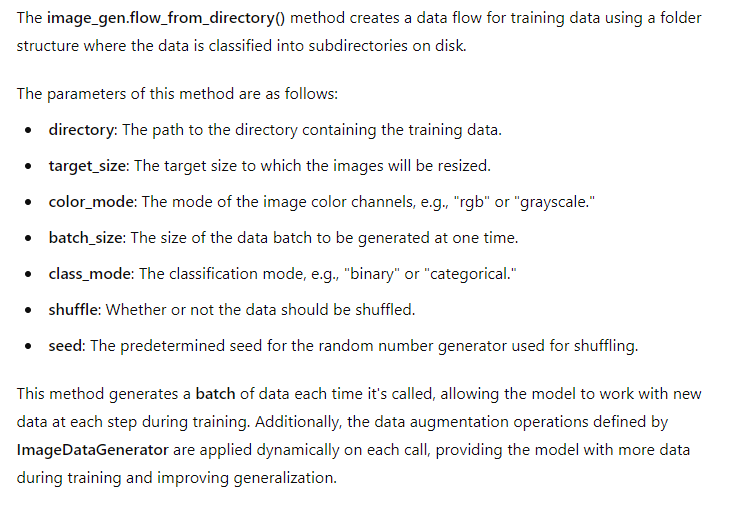

### No Image Generation for Test Data

In [44]:
"""test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=(130,130),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True, seed=42)"""

"test_image_gen = image_gen.flow_from_directory(test_path,\n                                               target_size=(130,130),\n                                               color_mode='rgb',\n                                               batch_size=batch_size,\n                                               class_mode='binary', shuffle=True, seed=42)"

**NOTE:** In fact, we don't need to apply **"image_gen"** to our test data; it can be applied to the training data for better learning. However, for the test data, we can test with the **original data**. Above, we applied it to the test data as well, but if we didn't want to apply it, we could define a separate **ImageDataGenerator()** for the test data and proceed as follows:

image_gen_test = ImageDataGenerator()

test_image_gen = image_gen_test.flow_from_directory(test_path,

                                               target_size=(130,130),
                                               
                                               color_mode='rgb',
                                               
                                               batch_size=batch_size,
                                               
                                               class_mode='binary', shuffle=True, seed=42)

In [45]:
# Empty image generator
image_gen_test = ImageDataGenerator()

test_image_gen = image_gen_test.flow_from_directory(test_path,
                                                   target_size=(130,130),                                                 
                                                   color_mode='rgb',                                                   
                                                   batch_size=batch_size,                                                   
                                                   class_mode='binary', shuffle=False, seed=42)  #If accuracy low at confussion matrix of test data --> make shuffle = False

Found 2600 images belonging to 2 classes.


In [46]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [47]:
test_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [48]:
results = model.fit(train_image_gen,epochs=10,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

Epoch 1/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 319s 406ms/step - accuracy: 0.7208 - loss: 0.8473 - val_accuracy: 0.9081 - val_loss: 0.2164
Epoch 2/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 304s 390ms/step - accuracy: 0.9193 - loss: 0.2171 - val_accuracy: 0.9438 - val_loss: 0.1766
Epoch 3/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 317s 406ms/step - accuracy: 0.9377 - loss: 0.1837 - val_accuracy: 0.9381 - val_loss: 0.1856
Epoch 4/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 312s 400ms/step - accuracy: 0.9471 - loss: 0.1605 - val_accuracy: 0.9423 - val_loss: 0.1725
Epoch 5/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 295s 378ms/step - accuracy: 0.9483 - loss: 0.1589 - val_accuracy: 0.9535 - val_loss: 0.1394
Epoch 6/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 294s 377ms/step - accuracy: 0.9531 - loss: 0.1471 - val_accuracy: 0.9365 - val_loss: 0.2090
Epoch 7/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 295s 378ms/step - accuracy: 0.9532 - loss: 0.1513 - val_accuracy: 0.9492 - val_loss: 0.1422
Epoch 8/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 295s 377ms/step - accuracy: 0.9522 -

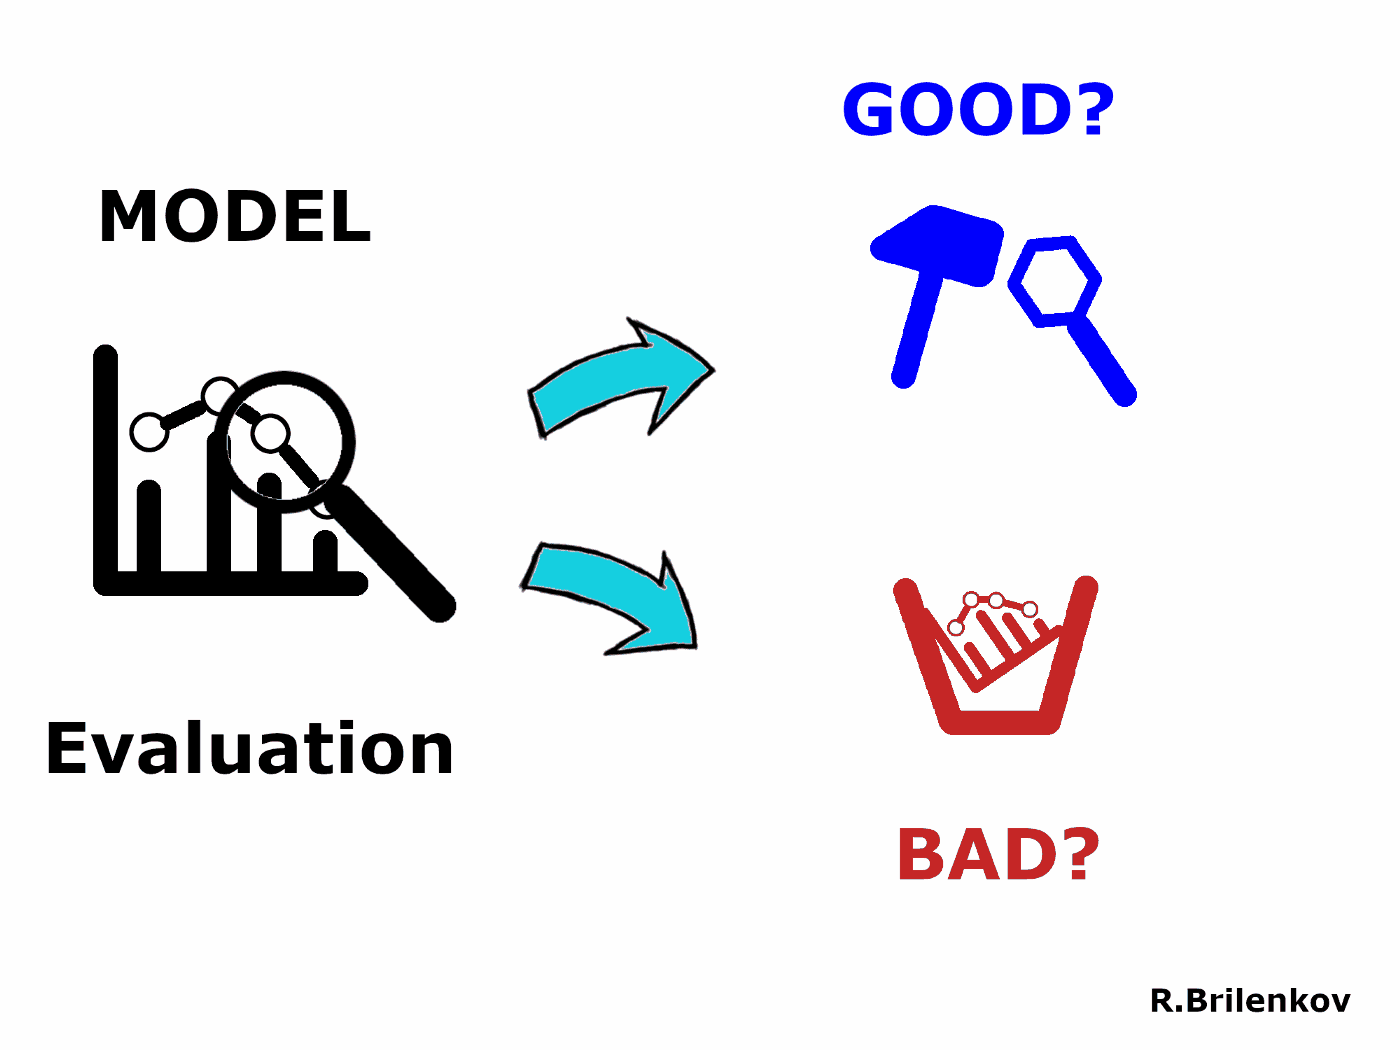

# Evaluating the Model

In [49]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.820979,0.456515,0.908077,0.216450
1,0.927799,0.202376,0.943846,0.176580
2,0.941301,0.177080,0.938077,0.185595
3,0.946831,0.162956,0.942308,0.172544
4,0.948433,0.157719,0.953462,0.139434


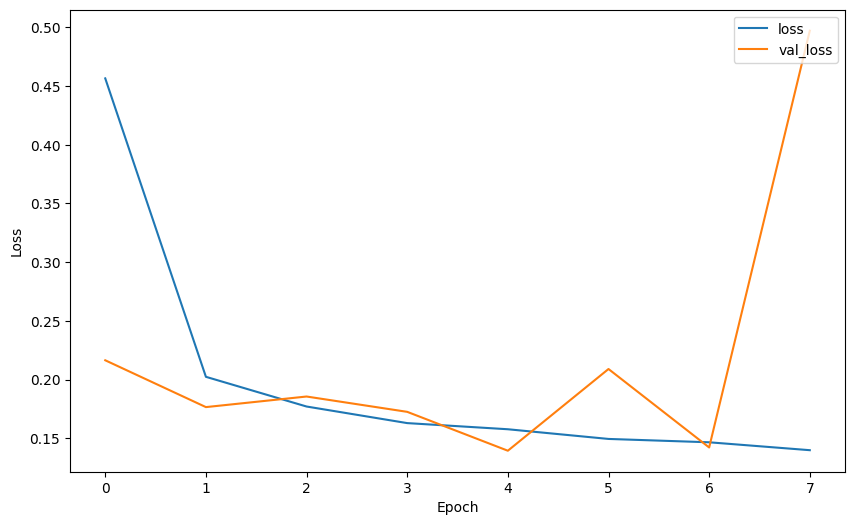

In [50]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

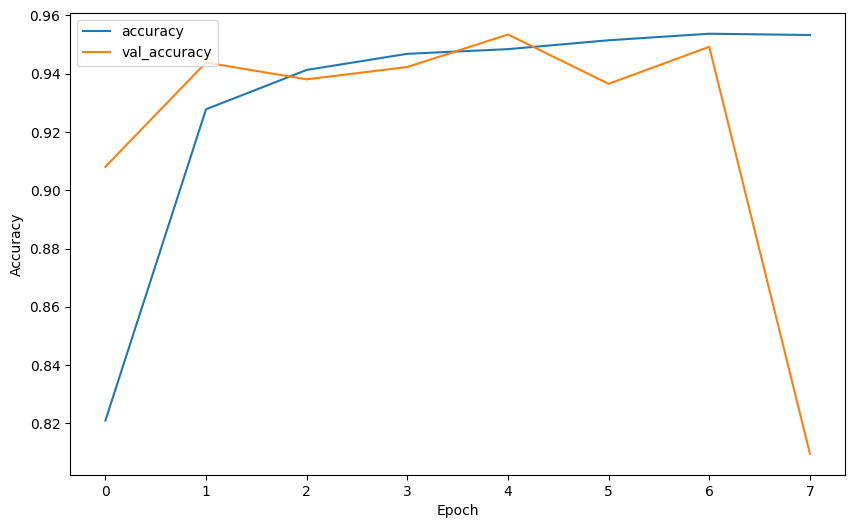

In [51]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()


First, I built a basic model: **2 Conv2D** and **2 MaxPooling** layers, and I saw a high score in the output. This means that my dataset is not very complex. If there is **overfitting**, I will add **Dropout** and **BatchNormalization** layers between the existing ones.


In [52]:
model.metrics_names

['loss', 'compile_metrics']

we should sample the images in the validation set exactly once(if you are planning to evaluate, you need to change the batch size of the valid generator to 1 or something that exactly divides the total num of samples in validation set), but the order doesn’t matter so let “shuffle” be True as it was earlier.

In [53]:
model.evaluate(test_image_gen)

82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9278 - loss: 0.1858


[0.49711138010025024, 0.8096153736114502]

In [54]:
from tensorflow.keras.preprocessing import image

In [55]:
pred_probabilities = model.predict(test_image_gen)

82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step


In [56]:
pred_probabilities

array([[2.3682136e-07],
       [8.7179535e-04],
       [3.5926267e-05],
       ...,
       [2.1816184e-01],
       [8.6750466e-01],
       [6.0837686e-01]], dtype=float32)

In [57]:
test_image_gen.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [58]:
pred_probabilities

array([[2.3682136e-07],
       [8.7179535e-04],
       [3.5926267e-05],
       ...,
       [2.1816184e-01],
       [8.6750466e-01],
       [6.0837686e-01]], dtype=float32)

In [59]:
predictions = pred_probabilities > 0.5

In [60]:
predictions[:100]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [61]:
from sklearn.metrics import classification_report,confusion_matrix

In [62]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.73      0.98      0.84      1300
           1       0.97      0.64      0.77      1300

    accuracy                           0.81      2600
   macro avg       0.85      0.81      0.80      2600
weighted avg       0.85      0.81      0.80      2600



In [63]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1275,   25],
       [ 470,  830]])

**Note:** This result is wonderful. If you meet **high score at training** section but **low scores in confussion matrix**, you should make "**Shuffle = False**" in image generation.

In [64]:
model.save('malaria_model_complex.h5')

* The code below is and alternative way for model loading (in the latest version, we save the model using the code below).

In [65]:
from tensorflow.keras.saving import save_model

save_model(model, 'malaria_model_complex.keras')

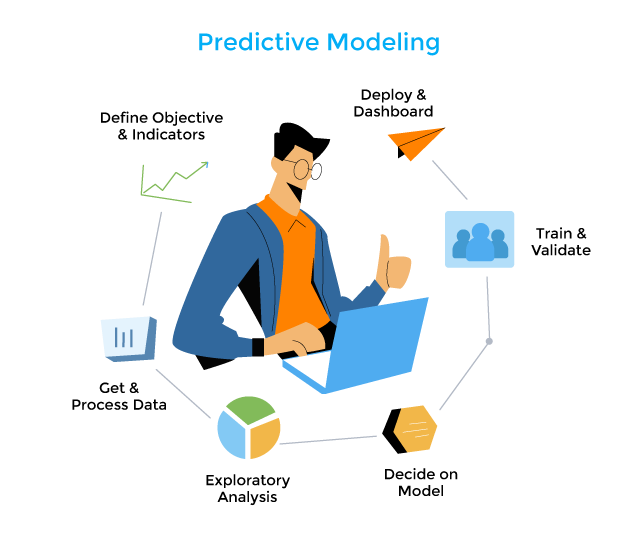

# Predicting on an Image

In [66]:
para_cell

'cell_images/train/parasitized/C100P61ThinF_IMG_20150918_144823_cell_158.png'

In [67]:
my_image = image.load_img(para_cell,target_size=image_shape)

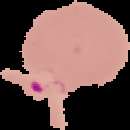

In [68]:
my_image

In [69]:
type(my_image)

PIL.Image.Image

In [70]:
my_image = image.img_to_array(my_image)

In [71]:
type(my_image)

numpy.ndarray

In [72]:
my_image.shape

(130, 130, 3)

In [73]:
my_image = np.expand_dims(my_image, axis=0)

In [74]:
my_image.shape

(1, 130, 130, 3)

In [75]:
model.predict(my_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


array([[2.030027e-05]], dtype=float32)

In [76]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [77]:
test_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [78]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the Model
model = tf.keras.models.load_model('malaria_model_complex.keras')

# Open the new image and convert it to a suitable format.
image = Image.open("moon.jpg")
# There are           \\  

image = image.resize((130, 130))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0) # Makes Tensor

# Predict
prediction = model.predict(image_array)

# Print the result
predicted_class = np.argmax(prediction)
print('Predicted Class:', predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Class: 0


This code snippet is used to **convert an image file** into a **numpy array**. The image file is first opened with the **Image** class, then converted to **RGB** format using the **convert** method. After that, the pixel values in the 0-255 range are scaled to the 0-1 range. The **expand_dims** method is used to increase the array's dimension by one, turning it into a **4-dimensional array** required for model prediction.

In [79]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the Model
model = tf.keras.models.load_model('malaria_model_complex.keras')

# Open the new image and convert it to a suitable format.
image = Image.open(r"sun.jpeg")
# !!               r   

image = image.resize((130, 130))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array)

# Print the predicted result
predicted_class = np.argmax(prediction)
print('Predicted Class:', predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Class: 0


In [80]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the model
model = tf.keras.models.load_model('malaria_model_complex.keras')

# Open the new image and convert it to a suitable format.
image = Image.open("teest.png")
image = image.resize((130, 130))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array)

# Print the predicted result
predicted_class = np.argmax(prediction)
print('Predicted Class:', predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Class: 0


**1- Start with a basic model (fewer convolutional layers, without dropout / batch normalization), and check the evaluation metrics.**

**2- If the results are not good, exclude image generation on test data (No\_image\_generation) + shuffle = False;
In order to Increase the model complexity.**

**3- If we improve the results, we can increase the number of convolutional layers + add BatchNormalization, Pooling + increase the number of hidden layers in ANN.**

**4- If there is an overfitting issue; add Dropout and/or BatchNormalization.**
